# Laser Off Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Set Instruments Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {params.device_line_1['v_attenuator_vals']['att_blue_v']}')
# yoko.current(0)
# Check shielding: box and fridge entry 

# Import

In [251]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")
import snspd
params = snspd.snspd('snspd11.yaml')

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 107


In [396]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd11.yaml')

# Instruments

In [8]:
params.device_line_1_name

'R9C9'

Negative voltages for this device due to polarity of four wire connection

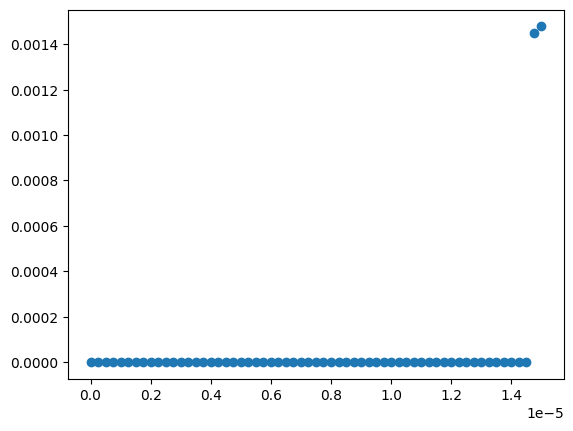

In [25]:
ID = params.device_line_1['IDs']['critical_current']
data = load_by_id(ID).get_parameter_data()
current = data['yoko_current']['yoko_current']
voltage = data['dmm_volt']['dmm_volt']
plt.plot(-current, -voltage, 'o')

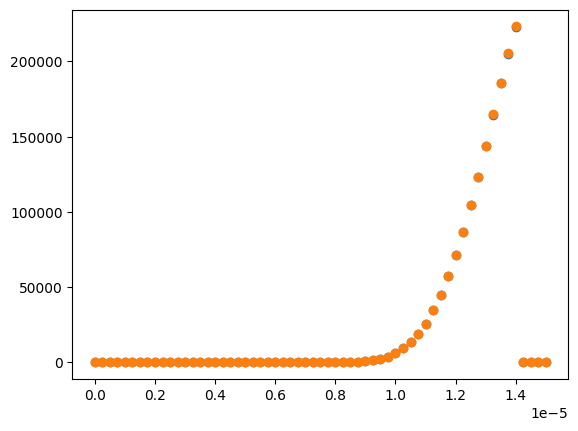

In [95]:
ID = params.device_line_1['IDs']['light_counts']
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['yoko_current']['yoko_current']
plt.plot(-current, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current, CR2, 'o', label='Threshold 2 (LOW)')

In [96]:
len(CR1[~np.isnan(CR1)])

61

# Dark Counts vs Current 

3660


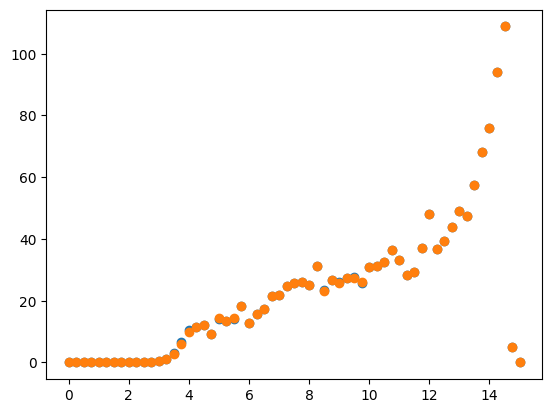

In [89]:
ID = params.device_line_1['IDs']['dark_counts']
data = load_by_id(ID).get_parameter_data()
CR1 = data['CR1']['CR1']
CR2 = data['CR2']['CR2']
current = data['yoko_current']['yoko_current']
plt.plot(-current*1e6, CR1, 'o', label='Threshold 1 (HIGH)')
plt.plot(-current*1e6, CR2, 'o', label='Threshold 2 (LOW)')
print(len(current))

In [94]:
len(CR1[~np.isnan(CR1)])

61

In [ ]:
current

# SDE 

In [75]:
Nphotons = load_by_id(params.Nphotons_ID).get_parameter_data()['Nphotons']['Nphotons']

In [76]:
v_att_range = params.att_blue_v_attenuator_range
v_att = np.arange(v_att_range['start'], v_att_range['stop'], v_att_range['step'])

In [77]:
len(v_att), len(Nphotons)

(43, 43)

In [78]:
v_att[-11]

np.float64(4.999999999999995)

Text(0.5, 1.0, 'R9C9')

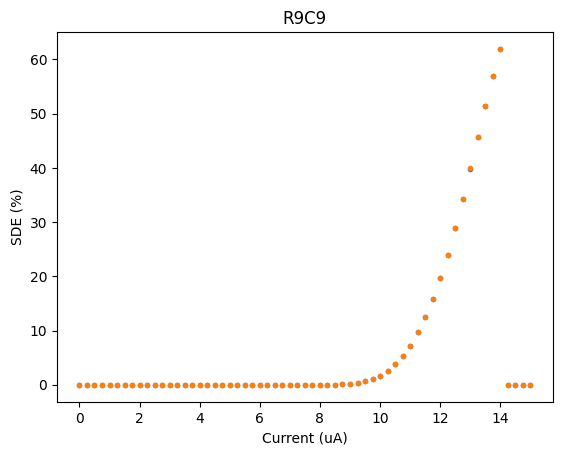

In [106]:
Nphotons_5v = Nphotons[-11]
currents = load_by_id(params.device_line_1['IDs']['light_counts']).get_parameter_data()['yoko_current']['yoko_current']
light_counts1 = load_by_id(params.device_line_1['IDs']['light_counts']).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(params.device_line_1['IDs']['light_counts']).get_parameter_data()['CR2']['CR2']
dark_counts1 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR1']['CR1']
dark_counts2 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR2']['CR2']
SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons_5v
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons_5v
plt.plot(-currents[~np.isnan(currents)]*1e6, 100*SDE1, '.')
plt.plot(-currents[~np.isnan(currents)]*1e6, 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel('Current (uA)')
plt.title(params.device_line_1['name'])

# Counts vs Attenuation

Text(0.5, 1.0, 'R9C9')

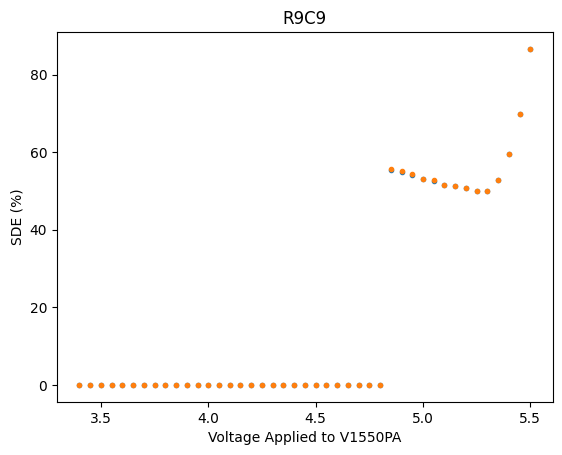

In [153]:
current = load_by_id(params.device_line_1['IDs']['counts_vs_attenuation']['run1']).get_parameter_data()['yoko_current']['yoko_current']
v_attenuator = np.arange(params.att_blue_v_attenuator_range['start'], params.att_blue_v_attenuator_range['stop'],  params.att_blue_v_attenuator_range['step'])
light_counts1 = load_by_id(params.device_line_1['IDs']['counts_vs_attenuation']['run1']).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(params.device_line_1['IDs']['counts_vs_attenuation']['run1']).get_parameter_data()['CR2']['CR2']
dark_counts1 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR1']['CR1'][idx] # select dark counts at 14uA
dark_counts2 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR2']['CR2'][idx]

SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons[::-1]
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons[::-1]
plt.plot(v_attenuator[::-1], 100*SDE1, '.')
plt.plot(v_attenuator[::-1], 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel(f'Voltage Applied to {params.att_blue_name}')
plt.title(params.device_line_1['name'])

In [176]:
IDsweep = params.device_line_1['IDs']['counts_vs_attenuation']['run2'][0]
current = load_by_id(IDsweep).get_parameter_data()['yoko_current']['yoko_current'][0]

In [177]:
current

np.float64(-1.2e-05)

In [178]:
dark_counts1 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR1']['CR1']

In [180]:
dark_counts1[20]

np.float64(14.1666666666667)

In [181]:
dcr_currents = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['yoko_current']['yoko_current']

In [200]:
test_current = np.abs(-12e-6)
currents = np.abs(dcr_currents)
# Set tolerance of index search based on steps between currents 
tol = np.diff(currents)[0]/2

current_out = currents[(currents > (test_current-tol)) & (currents < (test_current+tol))]
idx = np.where((currents > (test_current-tol)) & (currents < (test_current + tol)))

In [192]:
currents

array([0.0e+00, 2.5e-07, 5.0e-07, ...,     nan,     nan,     nan],
      shape=(3660,))

In [195]:
currents[currents > (test_current-tol)]

array([1.200e-05, 1.225e-05, 1.250e-05, 1.275e-05, 1.300e-05, 1.325e-05,
       1.350e-05, 1.375e-05, 1.400e-05, 1.425e-05, 1.450e-05, 1.475e-05,
       1.500e-05])

In [199]:
currents[(currents > (test_current-tol)) & (currents < (test_current+tol))]

array([1.2e-05])

In [205]:
idx, currout = match(12e-6, dcr_currents)

In [206]:
idx, currout

((array([48]),), array([1.2e-05]))

In [219]:
params.device_line_1['IDs']['counts_vs_attenuation']['run2'][4]

104

In [242]:
IDs = [params.device_line_1['IDs']['counts_vs_attenuation']['run1']] + params.device_line_1['IDs']['counts_vs_attenuation']['run2']

In [243]:
IDs

[87, 100, 101, 102, 103, 104, 105, 106, 107]

In [275]:
 params.device_line_1['IDs']['counts_vs_attenuation']['run3']

[110, 111, 112, 113]

In [333]:
IDs = [params.device_line_1['IDs']['counts_vs_attenuation']['run1']] + params.device_line_1['IDs']['counts_vs_attenuation']['run2'] + params.device_line_1['IDs']['counts_vs_attenuation']['run3']
min_idx = 0
max_idx = len(IDs)-1

v_attenuator = np.arange(params.att_blue_v_attenuator_range['start'], params.att_blue_v_attenuator_range['stop'],  params.att_blue_v_attenuator_range['step'])

idx_vend, _ = params.match(5.5, v_attenuator)

def plot_counts_vs_att(idx):
    IDs = [params.device_line_1['IDs']['counts_vs_attenuation']['run1']] + params.device_line_1['IDs']['counts_vs_attenuation']['run2'] + params.device_line_1['IDs']['counts_vs_attenuation']['run3']
    IDsweep = IDs[idx]
    Nphotons = load_by_id(params.Nphotons_ID).get_parameter_data()['Nphotons']['Nphotons']
    current = load_by_id(IDsweep).get_parameter_data()['yoko_current']['yoko_current'][0]
    light_counts1 = load_by_id(IDsweep).get_parameter_data()['CR1']['CR1'][:43]
    light_counts2 = load_by_id(IDsweep).get_parameter_data()['CR2']['CR2'][:43]
    total_counts = load_by_id(ID).get_parameter_data()['counts1']['counts1'][:43]
    
    # Get idx of dark counts corresponding to the current in this sweep 
    dcr_currents = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['yoko_current']['yoko_current']
    idx,curr_out = params.match(current, dcr_currents)
    # Get dark counts values 
    dark_counts1 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR1']['CR1'][idx] # select dark counts at 14uA
    dark_counts2 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR2']['CR2'][idx]
    
    SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons[::-1]
    SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons[::-1]
    plt.plot(v_attenuator[::-1], 100*SDE1, '.')
    plt.plot(v_attenuator[::-1], 100*SDE2, '.')
    plt.ylabel('SDE (%)')
    plt.xlabel(f'Voltage Applied to {params.att_blue_name}')
    plt.title(f'{params.device_line_1['name']} Ibias={current}\n{100*max(SDE1):.2f}%\n ID {IDsweep}')

interact(plot_counts_vs_att, idx=IntSlider(min=min_idx, max=max_idx, step=1, value=min_idx,
                                  continuous_update=False));



Check match:5.5 (test) = [5.5]?


interactive(children=(IntSlider(value=0, continuous_update=False, description='idx', max=12), Output(outputs=(…

In [287]:
len(v_attenuator)

43

Check match:-1.4e-05 (test) = [-1.4e-05]?
Check match:0.8662902845526732 (test) = [0.86629028]?
[2501.]
[2501.]
Effective reset time: [0.00039984] (0.4ms)
[2799.48501087]
Reset time for 100% efficiency: [0.00035721]
[75.83333333]
[0.86629028]
V: [5.5]

V: 4.999999999999995
191645.0
Effective reset time: 5.217981163088001e-06
360471.557889234
Reset time for 100% efficiency: 2.7741439736759505e-06


IndexError: index 10 is out of bounds for axis 0 with size 1

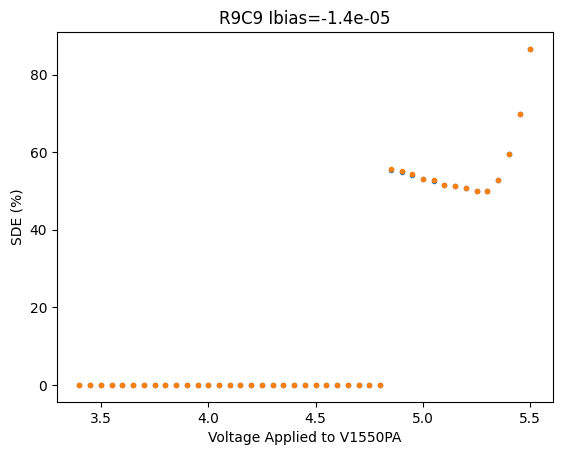

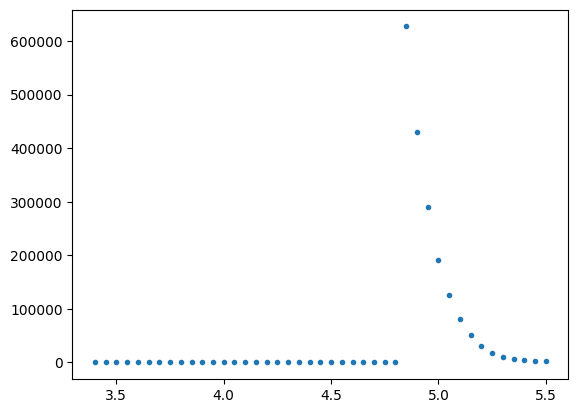

In [365]:
Nphotons = load_by_id(params.Nphotons_ID).get_parameter_data()['Nphotons']['Nphotons']

IDs = [params.device_line_1['IDs']['counts_vs_attenuation']['run1']] + params.device_line_1['IDs']['counts_vs_attenuation']['run2']
IDsweep = IDs[0]
current = load_by_id(IDsweep).get_parameter_data()['yoko_current']['yoko_current'][0]
v_attenuator = np.arange(params.att_blue_v_attenuator_range['start'], params.att_blue_v_attenuator_range['stop'],  params.att_blue_v_attenuator_range['step'])
light_counts1 = load_by_id(IDsweep).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDsweep).get_parameter_data()['CR2']['CR2']
total_counts1 = load_by_id(IDsweep).get_parameter_data()['total_counts1']['total_counts1']

# Get idx of dark counts corresponding to the current in this sweep 
dcr_currents = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['yoko_current']['yoko_current']
idx,curr_out = params.match(current, dcr_currents)
# Get dark counts values 
dark_counts1 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR1']['CR1'][idx] # select dark counts at 14uA
dark_counts2 = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['CR2']['CR2'][idx]

SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons[::-1]
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons[::-1]
plt.plot(v_attenuator[::-1], 100*SDE1, '.')
plt.plot(v_attenuator[::-1], 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel(f'Voltage Applied to {params.att_blue_name}')
plt.title(f'{params.device_line_1['name']} Ibias={current}')

plt.figure()
plt.plot(v_attenuator[::-1], light_counts1[~np.isnan(light_counts1)], '.')


idx, amt = params.match(max(SDE1), SDE1, tol = 0.001)
print(total_counts1[idx])
print(light_counts1[idx])
# Minimum reset time 
print(f'Effective reset time: {1/light_counts1[idx]} (0.4ms)') # 0.4ms 
print(Nphotons[::-1][idx])
print(f'Reset time for 100% efficiency: {1/Nphotons[::-1][idx]}')
print(dark_counts1[idx])
print((light_counts1[idx]-dark_counts1[idx])/Nphotons[::-1][idx])
print(f'V: {v_attenuator[::-1][idx]}\n')

v_att = v_attenuator[::-1]
idx = 10

print(f'V: {v_attenuator[::-1][idx]}')
print(light_counts1[idx])
# Minimum reset time 
print(f'Effective reset time: {1/light_counts1[idx]}') # 0.4ms 
print(Nphotons[::-1][idx])
print(f'Reset time for 100% efficiency: {1/Nphotons[::-1][idx]}')
print(dark_counts1[idx])
print((light_counts1[idx]-dark_counts1[idx])/Nphotons[::-1][idx])


np.float64(4.949999999999994)

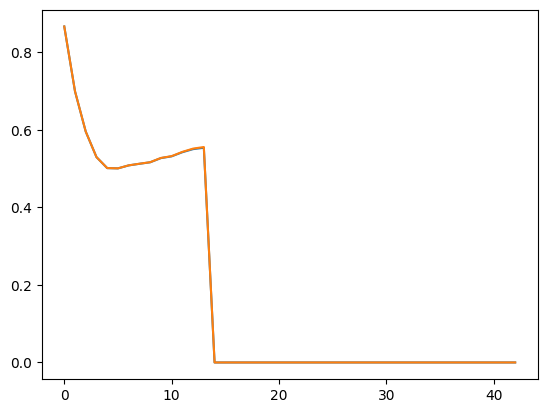

In [296]:
plt.plot(SDE1)
plt.plot(SDE2)


([<Axes: title={'center': 'Run #110, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='V', ylabel='cps'>,
  <Axes: title={'center': 'Run #110, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='V', ylabel='cps'>],
 [None, None])

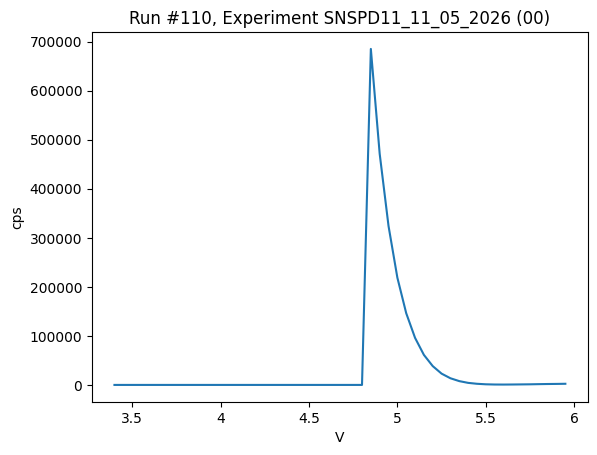

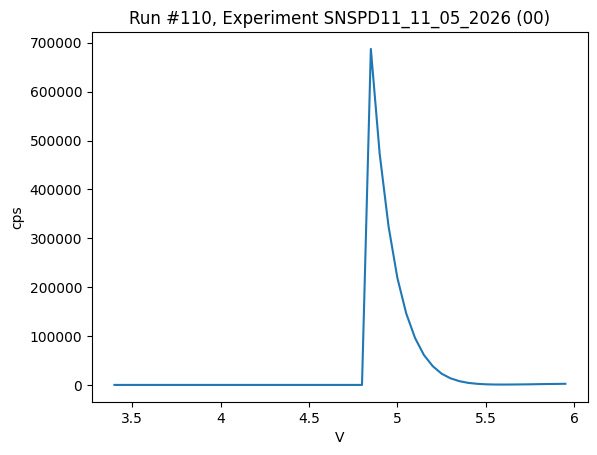

In [272]:
plot_by_id(110)

# Wavelength Sweep 

In [335]:
# Get the corresponding current 
currents_dcr = load_by_id(params.device_line_1['IDs']['dark_counts']).get_parameter_data()['yoko_current']['yoko_current']
idx, _ = params.match(-14e-6, currents_dcr)

Check match:-1.4e-05 (test) = [-1.4e-05]?


In [368]:
print(params.device_line_1['thresholds'])

{'range1': {'current': '-13e-6', 'threshold1': '342e-3', 'threshold2': '120e-3'}, 'range2': {'current': '-8e-6', 'threshold1': '198e-3', 'threshold2': '60e-3'}, 'range3': {'current': 0, 'threshold1': '78e-3', 'threshold2': '48e-3'}}


Check match:-1.4e-05 (test) = [-1.4e-05]?


Text(0.5, 1.0, 'SDE vs Wavelength\nID 124 2026-05-16 18:16:55\nR9C9')

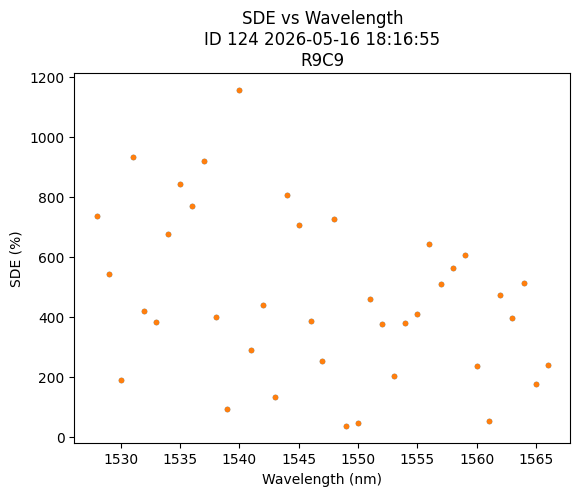

In [403]:
Nphotons_5_5v = Nphotons[-1]
IDwav = params.device_line_1['IDs']['wavelength']
wavelengths = load_by_id(IDwav).get_parameter_data()['wavelength_range']['wavelength_range']
light_counts1 = load_by_id(IDwav).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDwav).get_parameter_data()['CR2']['CR2']
total_counts1 = load_by_id(IDwav).get_parameter_data()['total_counts1']['total_counts1']

# Get the corresponding current 
IDdcr = params.device_line_1['IDs']['dark_counts']
currents_dcr = load_by_id(IDdcr).get_parameter_data()['yoko_current']['yoko_current']
idx, _ = params.match(-14e-6, currents_dcr)
dark_counts1 = load_by_id(IDdcr).get_parameter_data()['CR1']['CR1'][idx]
dark_counts2 = load_by_id(IDdcr).get_parameter_data()['CR2']['CR2'][idx]
SDE1 = (light_counts1[~np.isnan(light_counts1)]-dark_counts1[~np.isnan(dark_counts1)])/Nphotons_5_5v
SDE2 = (light_counts2[~np.isnan(light_counts2)]-dark_counts2[~np.isnan(dark_counts2)])/Nphotons_5_5v
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, 100*SDE1, '.')
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, 100*SDE2, '.')
plt.ylabel('SDE (%)')
plt.xlabel('Wavelength (nm)')
title = params.make_title(ID=IDwav, title='SDE vs Wavelength', extra=params.device_line_1['name'])
plt.title(title)


In [ ]:
Nphotons_5_5v = Nphotons[-1]
IDwav = params.device_line_1['IDs']['wavelength']
wavelengths = load_by_id(IDwav).get_parameter_data()['wavelength_range']['wavelength_range']
light_counts1 = load_by_id(IDwav).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(IDwav).get_parameter_data()['CR2']['CR2']
total_counts1 = load_by_id(IDwav).get_parameter_data()['total_counts1']['total_counts1']

# Get the corresponding current 
IDdcr = params.device_line_1['IDs']['dark_counts']
currents_dcr = load_by_id(IDdcr).get_parameter_data()['yoko_current']['yoko_current']
idx, _ = params.match(-14e-6, currents_dcr)
dark_counts1 = load_by_id(IDdcr).get_parameter_data()['CR1']['CR1'][idx]
dark_counts2 = load_by_id(IDdcr).get_parameter_data()['CR2']['CR2'][idx]

plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, light_counts1, '.')
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, light_counts2, '.')
plt.plot(wavelengths[~np.isnan(wavelengths)]*1e9, light_counts2, '.')
plt.ylabel('Count Rate (cps)')
plt.xlabel('Wavelength (nm)')
title = params.make_title(ID=IDwav, title='Counts vs Wavelength', extra=params.device_line_1['name'])
plt.title(title)


In [375]:
ID = params.device_line_1['IDs']['wavelength']
total_counts1 = load_by_id(ID).get_parameter_data()['total_counts1']['total_counts1']
meas_time = load_by_id(ID).get_parameter_data()['meas_time']['meas_time']

In [377]:
total_counts1

array([20719., 15268.,  5408., 26165., 11853., 10754., 19012., 23669.,
       21609., 25864., 11272.,  2689., 32468.,  8150., 12409.,  3778.,
       22700., 19850., 10895.,  7188., 20445.,  1091.,  1395., 12981.,
       10594.,  5728., 10694., 11519., 18127., 14381., 15824., 17051.,
        6732.,  1521., 13306., 11192., 14473.,  4996.,  6741.,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
      

In [371]:
Nphotons_5_5v

np.float64(2799.48501086902)

In [374]:
light_counts1

array([20719., 15268.,  5408., 26165., 11853., 10754., 19012., 23669.,
       21609., 25864., 11272.,  2689., 32468.,  8150., 12409.,  3778.,
       22700., 19850., 10895.,  7188., 20445.,  1091.,  1395., 12981.,
       10594.,  5728., 10694., 11519., 18127., 14381., 15824., 17051.,
        6732.,  1521., 13306., 11192., 14473.,  4996.,  6741.,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
      

In [359]:
total_counts1

array([2127., 2040., 2198., 2134., 2064., 2040., 2079., 2092., 2000.,
       1945., 1545., 1504., 1417., 1566., 1453., 1528., 1547., 1561.,
       1637., 1510.,  447.,  518.,  533.,  550.,  514.,  606.,  584.,
        526.,  558.,  572., 2639., 2573., 2539., 2697., 2629., 2639.,
       2604., 2635., 2588., 2622., 1159., 1187., 1114., 1237., 1177.,
       1233., 1140., 1227., 1144., 1235., 1179., 1150., 1059., 1035.,
       1038., 1046., 1025., 1073., 1099., 1050., 1909., 1838., 1885.,
       1897., 1910., 1963., 1875., 1956., 1911., 1868., 2507., 2473.,
       2415., 2257., 2276., 2277., 2409., 2322., 2336., 2397., 2320.,
       2324., 2256., 2072., 2197., 2168., 2072., 2101., 2186., 1913.,
       2582., 2578., 2505., 2529., 2667., 2549., 2661., 2668., 2581.,
       2544., 1155., 1127., 1194., 1100., 1146., 1171., 1033., 1089.,
       1102., 1155.,  265.,  287.,  268.,  260.,  247.,  274.,  305.,
        268.,  264.,  251., 3546., 3313., 3284., 3249., 3249., 3115.,
       3217., 3130.,

In [360]:
ID = 87
light_counts1 = load_by_id(ID).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(ID).get_parameter_data()['CR2']['CR2']
total_counts_benchmark = load_by_id(ID).get_parameter_data()['counts1']['counts1']

In [362]:
total_counts_benchmark

array([  236.,   270.,   247.,   248.,   276.,   242.,   245.,   250.,
         245.,   242.,   271.,   283.,   289.,   295.,   299.,   280.,
         268.,   268.,   286.,   297.,   390.,   424.,   401.,   401.,
         406.,   415.,   413.,   398.,   393.,   382.,   638.,   641.,
         660.,   619.,   646.,   614.,   687.,   643.,   613.,   625.,
        1064.,  1055.,  1125.,  1042.,  1054.,  1053.,  1081.,  1091.,
        1012.,  1099.,  1839.,  1849.,  1788.,  1812.,  1836.,  1780.,
        1817.,  1926.,  1825.,  1812.,  3012.,  3145.,  3136.,  3056.,
        3139.,  3146.,  3075.,  3092.,  3135.,  3135.,  5152.,  5184.,
        5047.,  4962.,  5036.,  5158.,  5043.,  5031.,  5002.,  5007.,
        8000.,  7997.,  8176.,  7942.,  8078.,  8131.,  7879.,  7967.,
        8044.,  8158., 12623., 12540., 12736., 12578., 12525., 12778.,
       12696., 12619., 12537., 12459., 19104., 19182., 19386., 19346.,
       19297., 18786., 19102., 19097., 19042., 19303., 29116., 29026.,
      

In [354]:
Nphotons

array([1.90074794e+09, 1.63340728e+09, 1.39181398e+09, 1.17990623e+09,
       9.93194972e+08, 8.28519053e+08, 6.87763718e+08, 5.65331692e+08,
       4.62219739e+08, 3.74833825e+08, 3.00900145e+08, 2.40234497e+08,
       1.89891971e+08, 1.49239221e+08, 1.16361658e+08, 8.97035973e+07,
       6.87844852e+07, 5.21624943e+07, 3.94094219e+07, 2.95462790e+07,
       2.19141457e+07, 1.62007202e+07, 1.18550291e+07, 8.64929020e+06,
       6.27085844e+06, 4.51093825e+06, 3.22898466e+06, 2.29031767e+06,
       1.61830602e+06, 1.13287352e+06, 7.81332480e+05, 5.35985390e+05,
       3.60471558e+05, 2.39158407e+05, 1.55576822e+05, 9.86806616e+04,
       6.10062846e+04, 3.63869652e+04, 2.11538373e+04, 1.19165906e+04,
       6.63091126e+03, 3.94873099e+03, 2.79948501e+03])

In [352]:
light_counts1

array([20719., 15268.,  5408., 26165., 11853., 10754., 19012., 23669.,
       21609., 25864., 11272.,  2689., 32468.,  8150., 12409.,  3778.,
       22700., 19850., 10895.,  7188., 20445.,  1091.,  1395., 12981.,
       10594.,  5728., 10694., 11519., 18127., 14381., 15824., 17051.,
        6732.,  1521., 13306., 11192., 14473.,  4996.,  6741.,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
      

In [351]:
dark_counts1

array([75.83333333])

In [356]:
v_att = load_by_id(ID).get_parameter_data()['v_attenuator']['v_attenuator']

In [357]:
v_att

array([5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5,
       5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5,
       5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

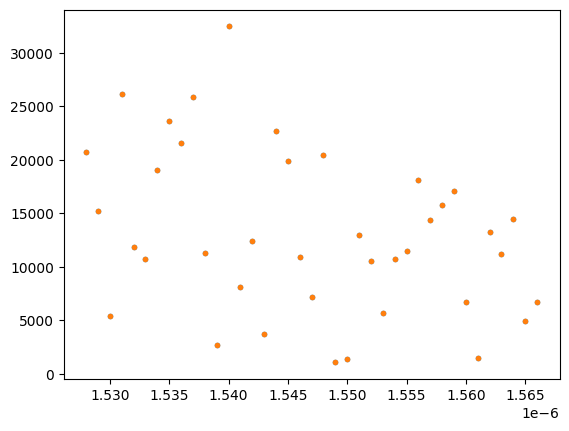

In [344]:
ID = params.device_line_1['IDs']['wavelength']
wavelengths = load_by_id(ID).get_parameter_data()['wavelength_range']['wavelength_range']
light_counts1 = load_by_id(ID).get_parameter_data()['CR1']['CR1']
light_counts2 = load_by_id(ID).get_parameter_data()['CR2']['CR2']
plt.plot(wavelengths, light_counts1, '.')
plt.plot(wavelengths, light_counts2, '.')

([<Axes: title={'center': 'Run #126, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='cps'>,
  <Axes: title={'center': 'Run #126, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='Current ($10^{-6}$ I)', ylabel='cps'>],
 [None, None])

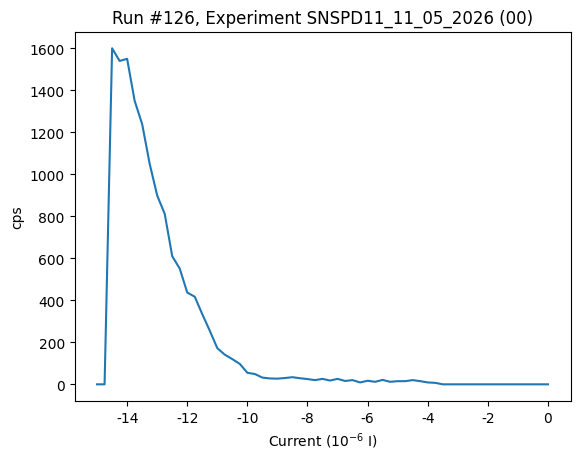

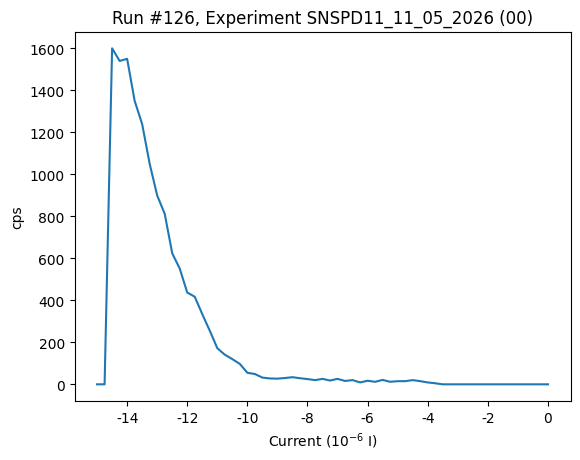

In [380]:
plot_by_id(126)

Text(0.5, 1.0, 'Counts vs Current\nID 126 2026-05-16 19:55:07')

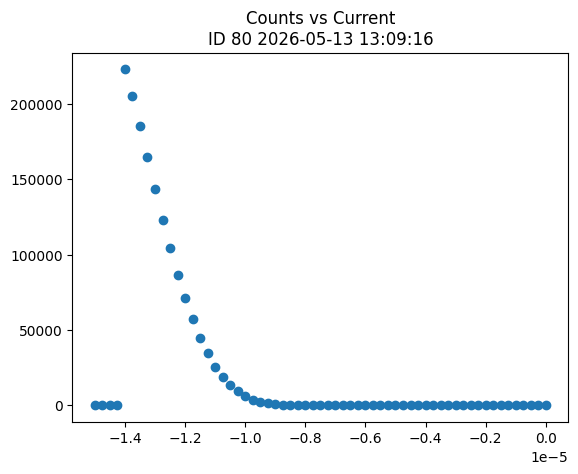

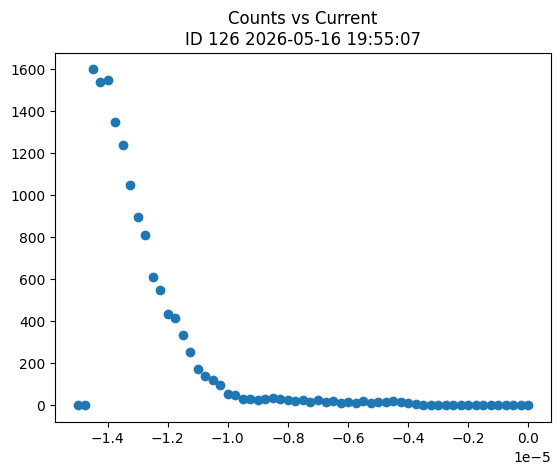

In [401]:
ID = params.device_line_1['IDs']['light_counts']
data = load_by_id(params.device_line_1['IDs']['light_counts']).get_parameter_data()
plt.plot(data['yoko_current']['yoko_current'], data['CR1']['CR1'], 'o')
title = params.make_title(ID=ID, title='Counts vs Current')
plt.title(title)

plt.figure()
ID = 126
data = load_by_id(ID).get_parameter_data()
plt.plot(data['CR1']['yoko_current'], data['CR1']['CR1'], 'o')
title = params.make_title(ID=ID, title='Counts vs Current')
plt.title(title)

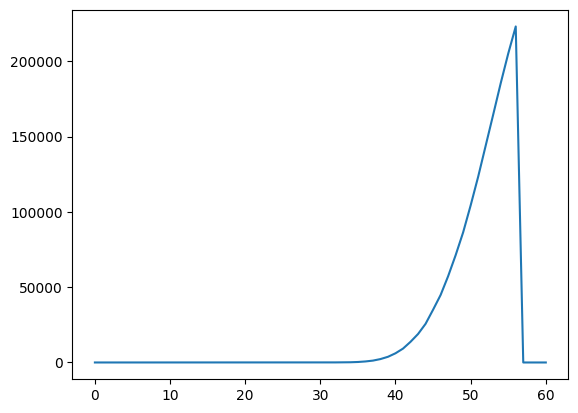

In [386]:
plt.plot(data['CR1']['CR1'])

([<Axes: title={'center': 'Run #125, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

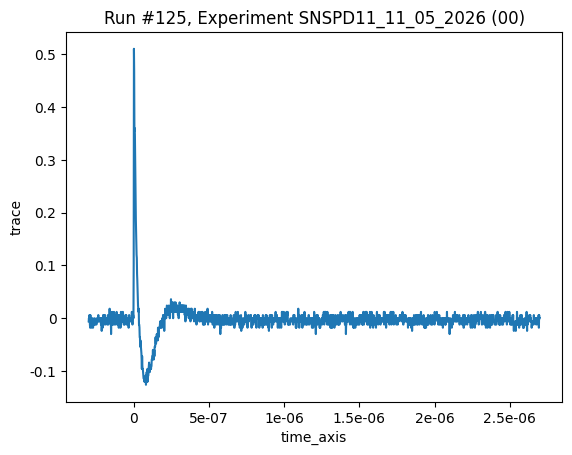

In [404]:
plot_by_id(125)